# Human Activity Classification from Radar using DCNN

## Import Libraries

In [1]:
import os
import warnings
import numpy as np
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
import subprocess
import sys
from scipy.ndimage import zoom
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, f1_score)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')

e:\Studies\Masters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import data as 80-20% Train-Test split format

In [2]:
PREPROCESSED_DIR   = '../../preprocessed'
PREPROCESS_SCRIPT = '../shared/preprocess_all.py'
TEST_SUBJECTS_FRAC = 0.20
RANDOM_SEED        = 42

OBS_DURATION_S = 2.0
IMG_H          = 128
IMG_W          = 128

ACTIVITY_NAMES = {
    1: 'Walking', 2: 'Sitting',  3: 'Standing',
    4: 'Drink water', 5: 'Pick up', 6: 'Fall'
}
class_names = [ACTIVITY_NAMES[i] for i in sorted(ACTIVITY_NAMES)]

In [3]:
# Only run if preprocessed files don't exist yet
if not os.path.exists(os.path.join(PREPROCESSED_DIR, 'spectrograms.npy')):
    print("Preprocessed data not found. Running preprocess_all.py ...")
    result = subprocess.run(
        [sys.executable, PREPROCESS_SCRIPT,
         '--data_dir', '../../data',
         '--out_dir',  PREPROCESSED_DIR],
        capture_output=True,
        text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("--- STDERR ---")
        print(result.stderr)
        raise RuntimeError("preprocess_all.py failed.")
    print("Preprocessing complete.")
else:
    print("Preprocessed data found. Skipping preprocess_all.py.")

specs   = np.load(os.path.join(PREPROCESSED_DIR, 'spectrograms.npy'), allow_pickle=True)
t_axes  = np.load(os.path.join(PREPROCESSED_DIR, 't_axes.npy'),       allow_pickle=True)
labels  = np.load(os.path.join(PREPROCESSED_DIR, 'labels.npy'))
persons = np.load(os.path.join(PREPROCESSED_DIR, 'persons.npy'))

print(f"Loaded {len(specs)} recordings")
print(f"labels : {labels.shape}   persons : {persons.shape}")

print("\nActivity distribution (recordings):")
act_counts = {}
for lbl in labels:
    act_counts[int(lbl)] = act_counts.get(int(lbl), 0) + 1
for act in sorted(act_counts):
    print(f"  {ACTIVITY_NAMES[act]:<15s}: {act_counts[act]}")

Preprocessed data found. Skipping preprocess_all.py.
Loaded 1754 recordings
labels : (1754,)   persons : (1754,)

Activity distribution (recordings):
  Walking        : 312
  Sitting        : 312
  Standing       : 311
  Drink water    : 311
  Pick up        : 311
  Fall           : 197


## Feature extraction - Spectrograms

In [4]:
def spectrogram_to_image(spec, img_h=IMG_H, img_w=IMG_W):
    """Resize the full spectrogram to (img_h, img_w) — one image per recording."""
    p1, p99 = np.percentile(spec, [1, 99])
    spec_norm = np.clip((spec - p1) / (p99 - p1 + 1e-12), 0.0, 1.0)
    img = zoom(spec_norm, (img_h / spec_norm.shape[0], img_w / spec_norm.shape[1]), order=1)
    return img.astype(np.float32)

all_imgs, all_labels, all_persons = [], [], []

for spec, label, person in tqdm(
        zip(specs, labels, persons),
        total=len(labels), desc='Imaging', unit='rec'):

    img = spectrogram_to_image(spec)
    all_imgs.append(img)
    all_labels.append(int(label) - 1)
    all_persons.append(int(person))

X       = np.stack(all_imgs)[:, np.newaxis, :, :]
y       = np.array(all_labels,  dtype=np.int64)
persons = np.array(all_persons, dtype=np.int16)

print(f"{X.shape[0]} images from {len(labels)} recordings")
print(f"X : {X.shape}   y : {y.shape}   persons : {persons.shape}")

# def spectrogram_and_cvd(spec, img_h=IMG_H, img_w=IMG_W):
#     # Channel 0: full-recording spectrogram
#     p1, p99 = np.percentile(spec, [1, 99])
#     spec_norm = np.clip((spec - p1) / (p99 - p1 + 1e-12), 0.0, 1.0)
#     ch0 = zoom(spec_norm, (img_h / spec_norm.shape[0], img_w / spec_norm.shape[1]), order=1)

#     # Channel 1: CVD
#     cvd = np.abs(np.fft.rfft(spec, axis=1))
#     p1, p99 = np.percentile(cvd, [1, 99])
#     cvd_norm = np.clip((cvd - p1) / (p99 - p1 + 1e-12), 0.0, 1.0)
#     ch1 = zoom(cvd_norm, (img_h / cvd_norm.shape[0], img_w / cvd_norm.shape[1]), order=1)

#     return np.stack([ch0, ch1]).astype(np.float32)   # (2, img_h, img_w)

# all_imgs, all_labels, all_persons = [], [], []

# for spec, label, person in tqdm(zip(specs, labels, persons), total=len(labels)):
#     img = spectrogram_and_cvd(spec)
#     all_imgs.append(img)
#     all_labels.append(int(label) - 1)
#     all_persons.append(int(person))

# X = np.stack(all_imgs)          # (N, 2, img_h, img_w) — no newaxis needed
# y = np.array(all_labels, dtype=np.int64)
# persons = np.array(all_persons, dtype=np.int16)

Imaging: 100%|██████████| 1754/1754 [00:12<00:00, 143.34rec/s]

1754 images from 1754 recordings
X : (1754, 1, 128, 128)   y : (1754,)   persons : (1754,)


## Train-Test Split

In [5]:
all_subjects  = sorted(set(persons.tolist()))
rng           = np.random.default_rng(RANDOM_SEED)
n_test        = max(1, round(len(all_subjects) * TEST_SUBJECTS_FRAC))
test_subjects = set(rng.choice(all_subjects, size=n_test, replace=False).tolist())

print(f"Total subjects: {len(all_subjects)}  |  Test subjects: {n_test}")
print(f"Test subjects : {sorted(test_subjects)}")

mask_test = np.array([p in test_subjects for p in persons])

X_train, y_train = X[~mask_test], y[~mask_test]
X_test,  y_test  = X[mask_test],  y[mask_test]

print(f"\nX_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")

Total subjects: 72  |  Test subjects: 14
Test subjects : [6, 7, 14, 28, 37, 40, 47, 53, 55, 63, 65, 66, 69, 72]

X_train : (1394, 1, 128, 128)  y_train : (1394,)
X_test  : (360, 1, 128, 128)   y_test  : (360,)


## Classification

### DCNN Model Definition

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

class ConvBlock(nn.Module):
    """Conv -> BN -> ReLU -> MaxPool -> Dropout block."""
    def __init__(self, in_ch, out_ch, dropout=0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout)
        )

    def forward(self, x):
        return self.block(x)


class DCNN(nn.Module):
    def __init__(self, num_classes=6, dropout=0.5,
                 n_conv_blocks=4, base_filters=32, fc_size=512):
        super().__init__()

        layers   = []
        in_ch    = 1
        out_ch   = base_filters
        img_size = 128

        for _ in range(n_conv_blocks):
            layers.append(ConvBlock(in_ch, out_ch, dropout=0.25))
            in_ch    = out_ch
            out_ch   = min(out_ch * 2, 512)
            img_size = img_size // 2

        self.features   = nn.Sequential(*layers)
        flat_size       = in_ch * img_size * img_size

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, fc_size),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_size, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


Device: cuda


### Training parameters and functions

In [7]:
# ── Training & Evaluation Config ──────────────────────────────────────────
# Hardcoded best hyperparameters from Optuna tuning (100 trials, best val acc: 0.8783)

NUM_CLASSES  = 6
N_FOLDS      = 5

LR           = 0.000172
BATCH_SIZE   = 32
DROPOUT      = 0.297
WEIGHT_DECAY = 0.000133
PATIENCE     = 20
EPOCHS_CV    = 100
EPOCHS_FINAL = 100
STEP_SIZE    = 20
GAMMA        = 0.43

N_CONV_BLOCKS = 5
BASE_FILTERS  = 64
FC_SIZE       = 512

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss  = 0.0
    y_true, y_pred = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(X_batch)
        y_true.extend(y_batch.cpu().tolist())
        y_pred.extend(out.argmax(dim=1).cpu().tolist())
    train_loss = running_loss / len(loader.dataset)
    train_acc  = accuracy_score(y_true, y_pred)
    return train_loss, train_acc


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for X_batch, y_batch in loader:
        preds = model(X_batch.to(device)).argmax(dim=1).cpu()
        y_true.extend(y_batch.tolist())
        y_pred.extend(preds.tolist())
    return np.array(y_true), np.array(y_pred)


def run_cv(X, y, device, n_folds=N_FOLDS):
    """5-fold stratified cross-validation with early stopping."""
    skf  = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_accuracies, fold_f1s = [], []
    oof_true, oof_pred        = [], []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n  Fold {fold}/{n_folds}")

        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        tr_loader  = DataLoader(
            TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
            batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(
            TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
            batch_size=BATCH_SIZE)

        model = DCNN(num_classes=NUM_CLASSES, dropout=DROPOUT,
             n_conv_blocks=N_CONV_BLOCKS,
             base_filters=BASE_FILTERS,
             fc_size=FC_SIZE).to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)


        best_acc      = 0.0
        no_improve    = 0
        best_weights  = None

        pbar = tqdm(range(EPOCHS_CV), desc=f"  Fold {fold} training", unit="epoch")
        for epoch in pbar:
            loss, train_acc = train_one_epoch(model, tr_loader, criterion, optimizer, device)
            scheduler.step()

            y_true_val, y_pred_val = evaluate(model, val_loader, device)
            val_acc = accuracy_score(y_true_val, y_pred_val)

            pbar.set_postfix(
                loss      = f"{loss:.4f}",
                train_acc = f"{train_acc:.4f}",
                val_acc   = f"{val_acc:.4f}",
                best      = f"{best_acc:.4f}",
                patience  = f"{no_improve}/{PATIENCE}"
            )

            if val_acc > best_acc:
                best_acc     = val_acc
                no_improve   = 0
                best_weights = model.state_dict().copy()
            else:
                no_improve += 1
                if no_improve >= PATIENCE:
                    print(f"\n  Early stopping at epoch {epoch + 1} "
                          f"(best val acc: {best_acc:.4f})")
                    break

        model.load_state_dict(best_weights)

        y_true_val, y_pred_val = evaluate(model, val_loader, device)
        acc = accuracy_score(y_true_val, y_pred_val)
        f1  = f1_score(y_true_val, y_pred_val, average='macro', zero_division=0)

        fold_accuracies.append(acc)
        fold_f1s.append(f1)
        oof_true.extend(y_true_val.tolist())
        oof_pred.extend(y_pred_val.tolist())

        print(f"  Fold {fold} -- Acc: {acc:.4f}  Macro-F1: {f1:.4f}")

    oof_true = np.array(oof_true)
    oof_pred = np.array(oof_pred)

    print(f"\n  CV mean Acc : {np.mean(fold_accuracies):.4f} +/- {np.std(fold_accuracies):.4f}")
    print(f"  CV mean F1  : {np.mean(fold_f1s):.4f} +/- {np.std(fold_f1s):.4f}")

    return {
        'fold_accuracies':      fold_accuracies,
        'fold_f1s':             fold_f1s,
        'mean_accuracy':        np.mean(fold_accuracies),
        'std_accuracy':         np.std(fold_accuracies),
        'mean_f1':              np.mean(fold_f1s),
        'std_f1':               np.std(fold_f1s),
        'oof_confusion_matrix': confusion_matrix(oof_true, oof_pred)
    }


def train_final(X, y, device):
    """Train final model on all training data with early stopping via a 10% holdout."""
    n_val      = max(1, int(0.1 * len(X)))
    idx        = np.random.default_rng(42).permutation(len(X))
    val_idx    = idx[:n_val]
    tr_idx     = idx[n_val:]

    tr_loader  = DataLoader(
        TensorDataset(torch.tensor(X[tr_idx]), torch.tensor(y[tr_idx])),
        batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X[val_idx]), torch.tensor(y[val_idx])),
        batch_size=BATCH_SIZE)

    model = DCNN(num_classes=NUM_CLASSES, dropout=DROPOUT,
             n_conv_blocks=N_CONV_BLOCKS,
             base_filters=BASE_FILTERS,
             fc_size=FC_SIZE).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

    best_acc     = 0.0
    no_improve   = 0
    best_weights = None

    pbar = tqdm(range(EPOCHS_FINAL), desc="Final model training", unit="epoch")
    for epoch in pbar:
        loss, train_acc = train_one_epoch(model, tr_loader, criterion, optimizer, device)
        scheduler.step()

        y_true_val, y_pred_val = evaluate(model, val_loader, device)
        val_acc = accuracy_score(y_true_val, y_pred_val)

        pbar.set_postfix(
            loss      = f"{loss:.4f}",
            train_acc = f"{train_acc:.4f}",
            val_acc   = f"{val_acc:.4f}",
            best      = f"{best_acc:.4f}",
            patience  = f"{no_improve}/{PATIENCE}"
        )

        if val_acc > best_acc:
            best_acc     = val_acc
            no_improve   = 0
            best_weights = model.state_dict().copy()
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"\n  Early stopping at epoch {epoch + 1} "
                      f"(best val acc: {best_acc:.4f})")
                break

    model.load_state_dict(best_weights)
    print(f"Final model trained -- best val acc: {best_acc:.4f}")
    return model

### 5-fold Cross Validation

In [8]:
print("Running 5-fold cross-validation...")
cv_results = run_cv(X_train, y_train, DEVICE)

print("\nTraining final model on all training data...")
final_model = train_final(X_train, y_train, DEVICE)

Running 5-fold cross-validation...

  Fold 1/5


  Fold 1 training:  44%|████▍     | 44/100 [01:22<01:44,  1.87s/epoch, best=0.9140, loss=0.0742, patience=19/20, train_acc=0.9776, val_acc=0.8961]



  Early stopping at epoch 45 (best val acc: 0.9140)
  Fold 1 -- Acc: 0.8961  Macro-F1: 0.8998

  Fold 2/5


  Fold 2 training:  46%|████▌     | 46/100 [01:25<01:40,  1.85s/epoch, best=0.9355, loss=0.0802, patience=19/20, train_acc=0.9740, val_acc=0.9319]



  Early stopping at epoch 47 (best val acc: 0.9355)
  Fold 2 -- Acc: 0.9319  Macro-F1: 0.9369

  Fold 3/5


...


  Early stopping at epoch 64 (best val acc: 0.9642)
  Fold 4 -- Acc: 0.9462  Macro-F1: 0.9478

  Fold 5/5


  Fold 5 training:  82%|████████▏ | 82/100 [02:33<00:33,  1.88s/epoch, best=0.9568, loss=0.0610, patience=19/20, train_acc=0.9803, val_acc=0.9460]



  Early stopping at epoch 83 (best val acc: 0.9568)
  Fold 5 -- Acc: 0.9460  Macro-F1: 0.9481

  CV mean Acc : 0.9319 +/- 0.0187
  CV mean F1  : 0.9350 +/- 0.0181

Training final model on all training data...


Final model training:  58%|█████▊    | 58/100 [01:55<01:23,  1.99s/epoch, best=0.9353, loss=0.0749, patience=19/20, train_acc=0.9753, val_acc=0.9137]


  Early stopping at epoch 59 (best val acc: 0.9353)
Final model trained -- best val acc: 0.9353


### Evaluating on Test set

In [9]:
def evaluate_test(model, X, y, device):
    """Run final model on test set and return metrics."""
    loader = DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y)),
        batch_size=BATCH_SIZE)

    y_true, y_pred = evaluate(model, loader, device)

    return {
        'accuracy':       accuracy_score(y_true, y_pred),
        'macro_f1':       f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_per_class':   f1_score(y_true, y_pred, average=None,    zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'y_true': y_true,
        'y_pred': y_pred
    }


def print_results(results, class_names):
    print(f"\n{'='*60}")
    print(f"  TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"  Overall Accuracy : {results['accuracy']:.4f}  ({results['accuracy']*100:.2f}%)")
    print(f"  Macro F1-Score   : {results['macro_f1']:.4f}")
    print(f"\n  Per-class F1 scores:")
    for i, name in enumerate(class_names):
        print(f"    {name:<15s}: {results['f1_per_class'][i]:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(results['y_true'], results['y_pred'],
                                target_names=class_names, zero_division=0))


def plot_confusion_matrix(cm, title, class_names, filepath=None):
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm_norm[i, j]:.2f}\n({cm[i, j]})',
                    ha='center', va='center', color=color, fontsize=8)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    ax.set_title(title)
    plt.tight_layout()
    if filepath:
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"Saved: {filepath}")
    plt.show()


def plot_cv_accuracy(cv_results, filepath=None):
    accs = cv_results['fold_accuracies']
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(range(1, N_FOLDS + 1), accs, color='steelblue', alpha=0.8)
    ax.axhline(cv_results['mean_accuracy'], color='red', linestyle='--',
               label=f"Mean = {cv_results['mean_accuracy']:.3f}")
    ax.set_xlabel('Fold')
    ax.set_ylabel('Validation Accuracy')
    ax.set_title('5-Fold Cross-Validation Accuracy')
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    if filepath:
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"Saved: {filepath}")
    plt.show()

Evaluating on test set...

  TEST SET RESULTS
  Overall Accuracy : 0.9139  (91.39%)
  Macro F1-Score   : 0.9181

  Per-class F1 scores:
    Walking        : 0.9921
    Sitting        : 0.9440
    Standing       : 0.9500
    Drink water    : 0.8235
    Pick up        : 0.8099
    Fall           : 0.9890

  Classification Report:
              precision    recall  f1-score   support

     Walking       1.00      0.98      0.99        64
     Sitting       0.95      0.94      0.94        63
    Standing       1.00      0.90      0.95        63
 Drink water       0.76      0.90      0.82        62
     Pick up       0.84      0.78      0.81        63
        Fall       0.98      1.00      0.99        45

    accuracy                           0.91       360
   macro avg       0.92      0.92      0.92       360
weighted avg       0.92      0.91      0.92       360

Saved: ../../results/confusion_matrices/dcnn_cv_confusion_matrix.png


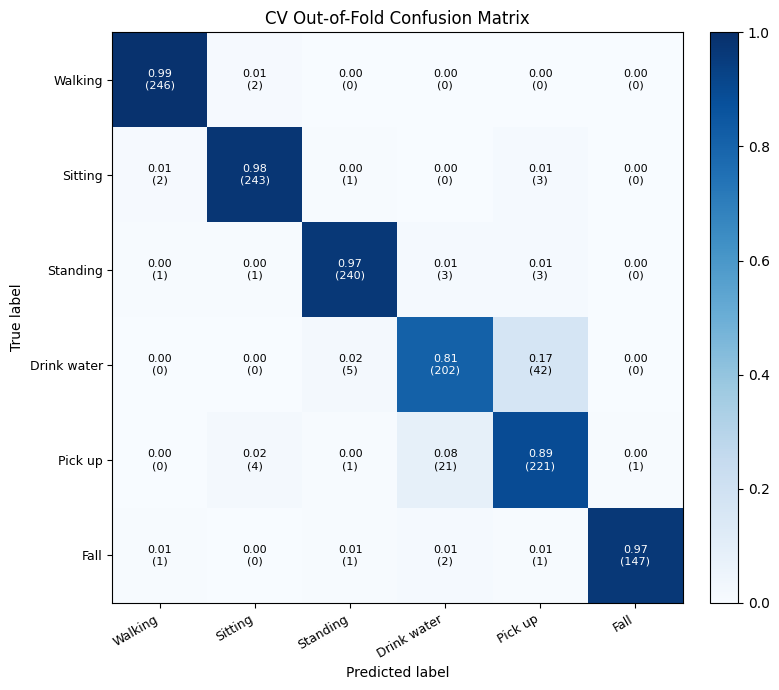

Saved: ../../results/confusion_matrices/dcnn_test_confusion_matrix.png


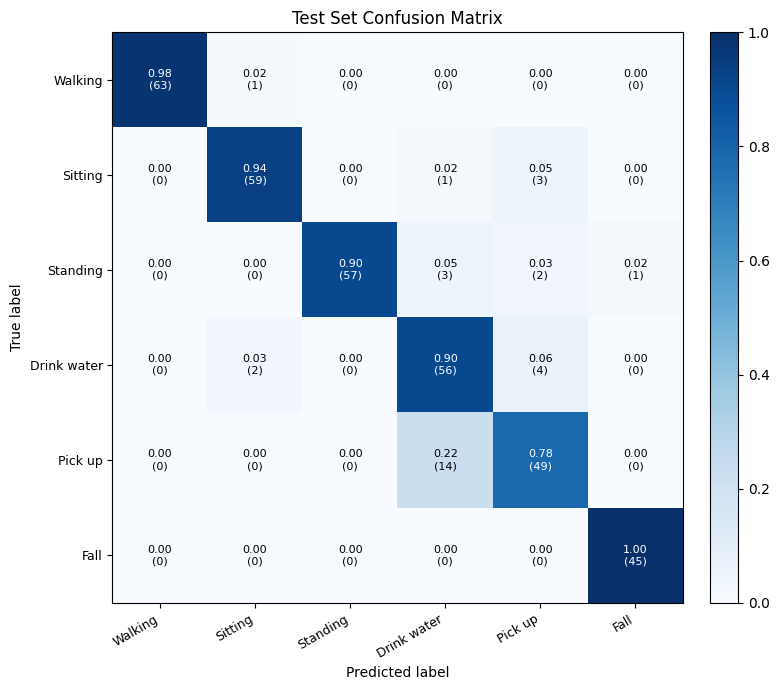

Model saved to ../../trained_models/dcnn_final_model.pth


In [10]:
# Run and save the model
print("Evaluating on test set...")
test_results = evaluate_test(final_model, X_test, y_test, DEVICE)

print_results(test_results, class_names)

# plot_cv_accuracy(cv_results,         filepath='../trained_models/cv_fold_accuracy.png')
plot_confusion_matrix(cv_results['oof_confusion_matrix'],
                      'CV Out-of-Fold Confusion Matrix',
                      class_names, filepath='../../results/confusion_matrices/dcnn_cv_confusion_matrix.png')
plot_confusion_matrix(test_results['confusion_matrix'],
                      'Test Set Confusion Matrix',
                      class_names, filepath='../../results/confusion_matrices/dcnn_test_confusion_matrix.png')

torch.save(final_model.state_dict(), '../../trained_models/dcnn_final_model.pth')
print("Model saved to ../../trained_models/dcnn_final_model.pth")

In [11]:
print(f"\n{'='*60}")
print(f"  SUMMARY")
print(f"{'='*60}")
print(f"  CV  mean accuracy : {cv_results['mean_accuracy']:.4f} +/- {cv_results['std_accuracy']:.4f}")
print(f"  CV  mean macro-F1 : {cv_results['mean_f1']:.4f} +/- {cv_results['std_f1']:.4f}")
print(f"  Test accuracy     : {test_results['accuracy']:.4f}")
print(f"  Test macro-F1     : {test_results['macro_f1']:.4f}")
print(f"{'='*60}")


  SUMMARY
  CV  mean accuracy : 0.9319 +/- 0.0187
  CV  mean macro-F1 : 0.9350 +/- 0.0181
  Test accuracy     : 0.9139
  Test macro-F1     : 0.9181


### Hyperparameter Tuning

In [ ]:
# ── Tuning config ──
N_TRIALS      = 100       # number of hyperparameter combinations to try
EPOCHS_TUNE   = 50       # shorter epochs during tuning for speed
PATIENCE_TUNE = 10        # early stopping patience during tuning
VAL_FRAC      = 0.20     # fraction of training data used as validation during tuning

# ── Fixed validation split for tuning (same split every trial for fair comparison) ──
n_val      = max(1, int(VAL_FRAC * len(X_train)))
idx        = np.random.default_rng(42).permutation(len(X_train))
tune_val   = idx[:n_val]
tune_tr    = idx[n_val:]

X_tune_tr  = X_train[tune_tr];  y_tune_tr  = y_train[tune_tr]
X_tune_val = X_train[tune_val]; y_tune_val = y_train[tune_val]

def objective(trial):
    # ── Training hyperparameters ──
    lr           = trial.suggest_float('lr',           1e-4, 1e-2, log=True)
    batch_size   = trial.suggest_categorical('batch_size',   [16, 32, 64])
    dropout      = trial.suggest_float('dropout',      0.2,  0.6)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    step_size    = trial.suggest_categorical('step_size',    [5, 10, 20])
    gamma        = trial.suggest_float('gamma',        0.1,  0.7)

    # ── Architecture hyperparameters ──
    n_conv_blocks = trial.suggest_int('n_conv_blocks', 2, 5)
    base_filters  = trial.suggest_categorical('base_filters', [16, 32, 64])
    fc_size       = trial.suggest_categorical('fc_size',      [256, 512, 1024])

    tr_loader  = DataLoader(
        TensorDataset(torch.tensor(X_tune_tr),  torch.tensor(y_tune_tr)),
        batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_tune_val), torch.tensor(y_tune_val)),
        batch_size=batch_size)

    model     = DCNN(num_classes=NUM_CLASSES, dropout=dropout,
                     n_conv_blocks=n_conv_blocks,
                     base_filters=base_filters,
                     fc_size=fc_size).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

    best_acc     = 0.0
    no_improve   = 0
    best_weights = None

    for epoch in range(EPOCHS_TUNE):
        train_one_epoch(model, tr_loader, criterion, optimizer, device=DEVICE)
        scheduler.step()

        y_true_val, y_pred_val = evaluate(model, val_loader, device=DEVICE)
        val_acc = accuracy_score(y_true_val, y_pred_val)

        if val_acc > best_acc:
            best_acc     = val_acc
            no_improve   = 0
            best_weights = model.state_dict().copy()
        else:
            no_improve += 1
            if no_improve >= PATIENCE_TUNE:
                break

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_acc


# ── Run Optuna ──
sampler = TPESampler(seed=42)
study   = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)

optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial spam

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

# ── Results ──
best = study.best_params
print(f"\nBest trial -- Val Acc: {study.best_value:.4f}")
print(f"Best hyperparameters:")
for k, v in best.items():
    print(f"  {k:<20s}: {v}")

# ── Update config ──
LR            = best['lr']
BATCH_SIZE    = best['batch_size']
DROPOUT       = best['dropout']
WEIGHT_DECAY  = best['weight_decay']
STEP_SIZE     = best['step_size']
GAMMA         = best['gamma']
N_CONV_BLOCKS = best['n_conv_blocks']
BASE_FILTERS  = best['base_filters']
FC_SIZE       = best['fc_size']

print(f"\nTraining config updated with best hyperparameters.")
print(f"  LR           : {LR}")
print(f"  BATCH_SIZE   : {BATCH_SIZE}")
print(f"  DROPOUT      : {DROPOUT}")
print(f"  WEIGHT_DECAY : {WEIGHT_DECAY}")
print(f"  STEP_SIZE    : {STEP_SIZE}")
print(f"  GAMMA        : {GAMMA}")
print(f"  N_CONV_BLOCKS: {N_CONV_BLOCKS}")
print(f"  BASE_FILTERS : {BASE_FILTERS}")
print(f"  FC_SIZE      : {FC_SIZE}")

[I 2026-05-31 15:53:18,201] A new study created in memory with name: no-name-919ba12d-b325-4971-8f11-dbd410177b5a
Best trial: 62. Best value: 0.878292: 100%|██████████| 100/100 [4:32:00<00:00, 163.20s/it] 


Best trial -- Val Acc: 0.8783
Best hyperparameters:
  lr                  : 0.00017222869662454051
  batch_size          : 32
  dropout             : 0.29696959596962613
  weight_decay        : 0.0001326288461650197
  step_size           : 20
  gamma               : 0.43154348252215174
  n_conv_blocks       : 5
  base_filters        : 64
  fc_size             : 512

Training config updated with best hyperparameters.
  LR           : 0.00017222869662454051
  BATCH_SIZE   : 32
  DROPOUT      : 0.29696959596962613
  WEIGHT_DECAY : 0.0001326288461650197
  STEP_SIZE    : 20
  GAMMA        : 0.43154348252215174
  N_CONV_BLOCKS: 5
  BASE_FILTERS : 64
  FC_SIZE      : 512


### Spectrogram Threshold effect viz

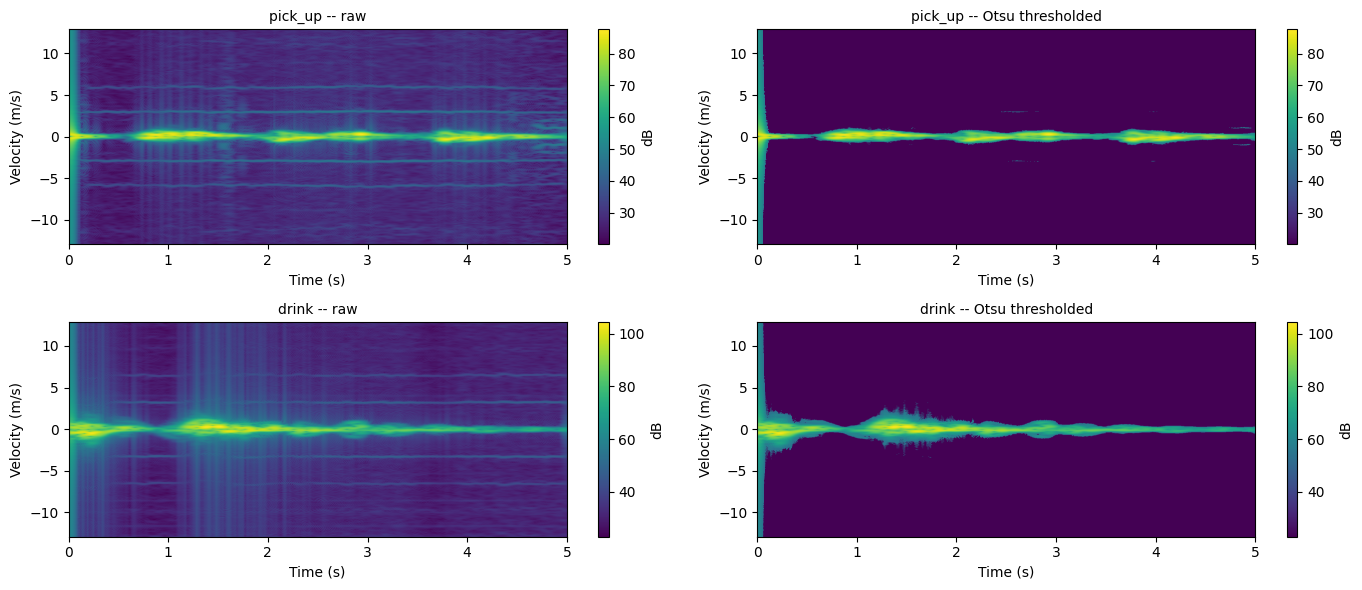

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../../code/shared')   # adjust path to match your layout

from data_loader       import load_dat_file, parse_filename
from signal_processing import compute_spectrogram, otsu_threshold

# Pick one file per class to visualise -- change paths to match your data dir
sample_files = {
    'pick_up':  '../../data/1 December 2017 Dataset/5P42A05R03.dat',
    'drink':  '../../data/1 December 2017 Dataset/4P36A04R01.dat',
}

fig, axes = plt.subplots(len(sample_files), 2,
                          figsize=(14, 3 * len(sample_files)))

for row, (activity, fpath) in enumerate(sample_files.items()):
    radar = load_dat_file(fpath)
    spec, d_axis, t_axis = compute_spectrogram(radar, apply_threshold=False)

    spec_db_raw    = 20 * np.log10(spec + 1e-10)
    spec_thresh    = otsu_threshold(spec)
    spec_db_thresh = 20 * np.log10(spec_thresh + 1e-10)

    extent = [t_axis[0], t_axis[-1], d_axis[-1], d_axis[0]]
    vmin, vmax = spec_db_raw.min(), spec_db_raw.max()

    for col, (img, title) in enumerate([
        (spec_db_raw,    f'{activity} -- raw'),
        (spec_db_thresh, f'{activity} -- Otsu thresholded'),
    ]):
        ax = axes[row, col]
        im = ax.imshow(img, aspect='auto', origin='upper',
                       extent=extent, vmin=vmin, vmax=vmax,
                       cmap='viridis')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Velocity (m/s)')
        plt.colorbar(im, ax=ax, label='dB')

plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150)
plt.show()